<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/53DecisionTreeAndRandomForestPracticeLastFive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%load_ext cuml.accel

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/content/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
import matplotlib.pyplot as plt

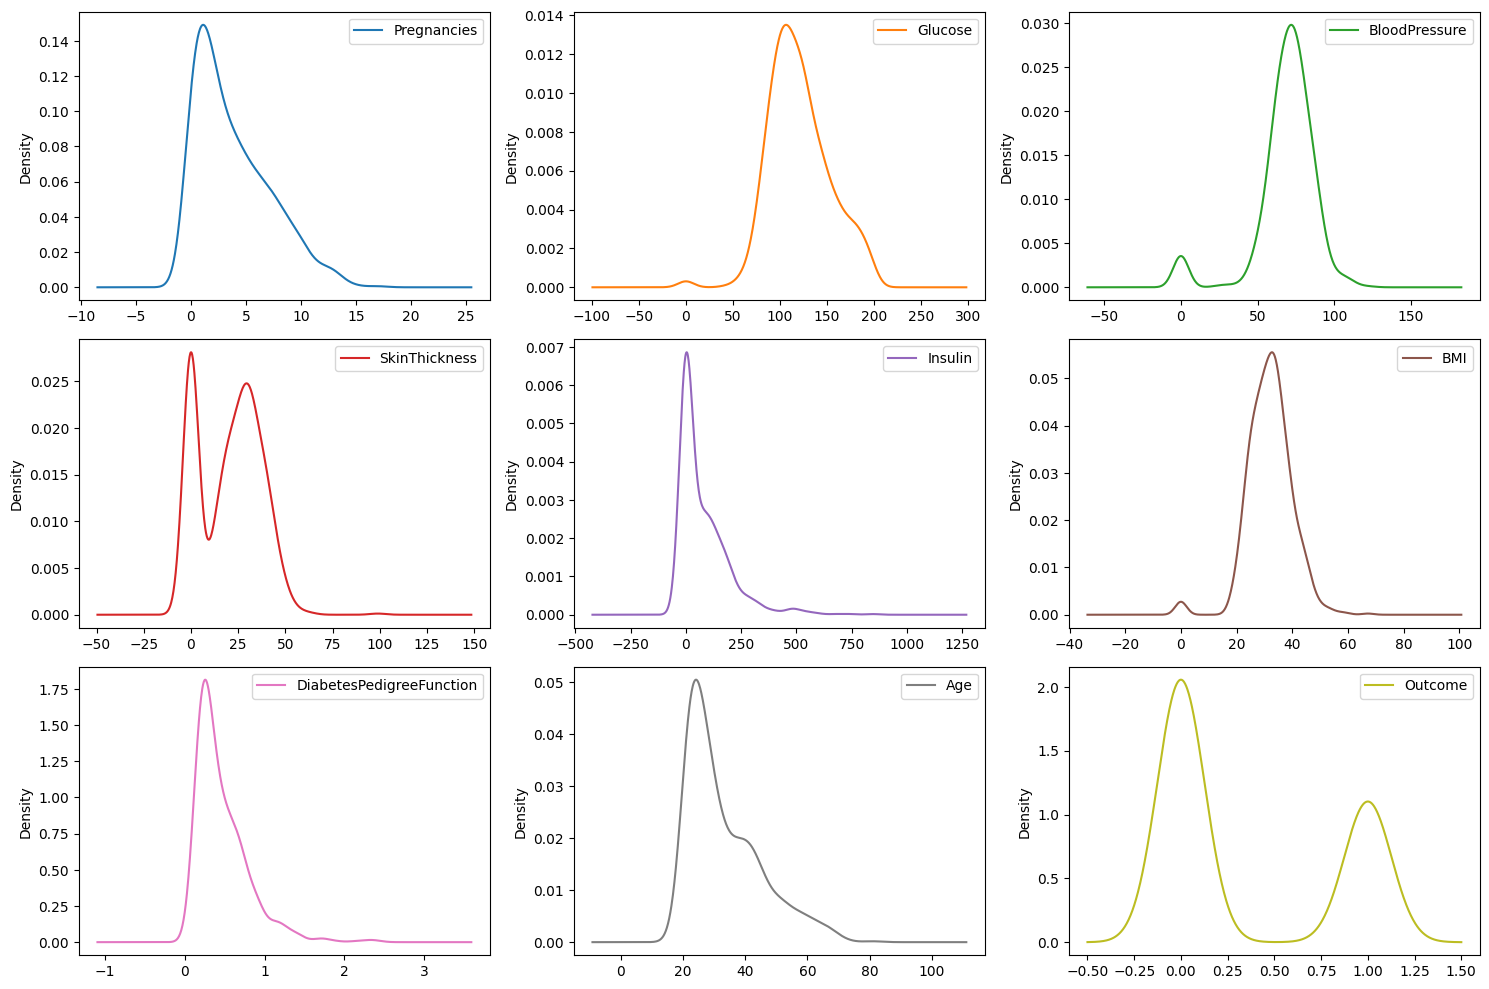

In [7]:
df.select_dtypes(include=['number']).plot(
    kind='kde',
    subplots=True,
    layout=(-1, 3),  # Automatically determines rows, locks columns to 3
    figsize=(15, 10),
    sharex=False     # Allows individual columns to use their own x-axis scale
)

plt.tight_layout()

In [8]:
import numpy as np

columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X = df.drop(['Outcome'],axis=1)
y = df['Outcome']
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [12]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [13]:
imputer_transformer = ColumnTransformer(
    transformers=[
        ('age',SimpleImputer(missing_values=np.nan , strategy='median'),['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'])
    ],
    remainder='passthrough',
    verbose_feature_names_out = False
)
imputer_transformer.set_output(transform='pandas')

imputer_transformer.fit(X_train)

X_train = imputer_transformer.transform(X_train)
X_test = imputer_transformer.transform(X_test)

In [14]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 353 to 107
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Glucose                   614 non-null    float64
 1   BloodPressure             614 non-null    float64
 2   SkinThickness             614 non-null    float64
 3   Insulin                   614 non-null    float64
 4   BMI                       614 non-null    float64
 5   Pregnancies               614 non-null    int64  
 6   DiabetesPedigreeFunction  614 non-null    float64
 7   Age                       614 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 43.2 KB


In [15]:
numerical_cols_for_outliers_split = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for col in numerical_cols_for_outliers_split:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower_bound, upper_bound)
    X_test[col] = X_test[col].clip(lower_bound, upper_bound)

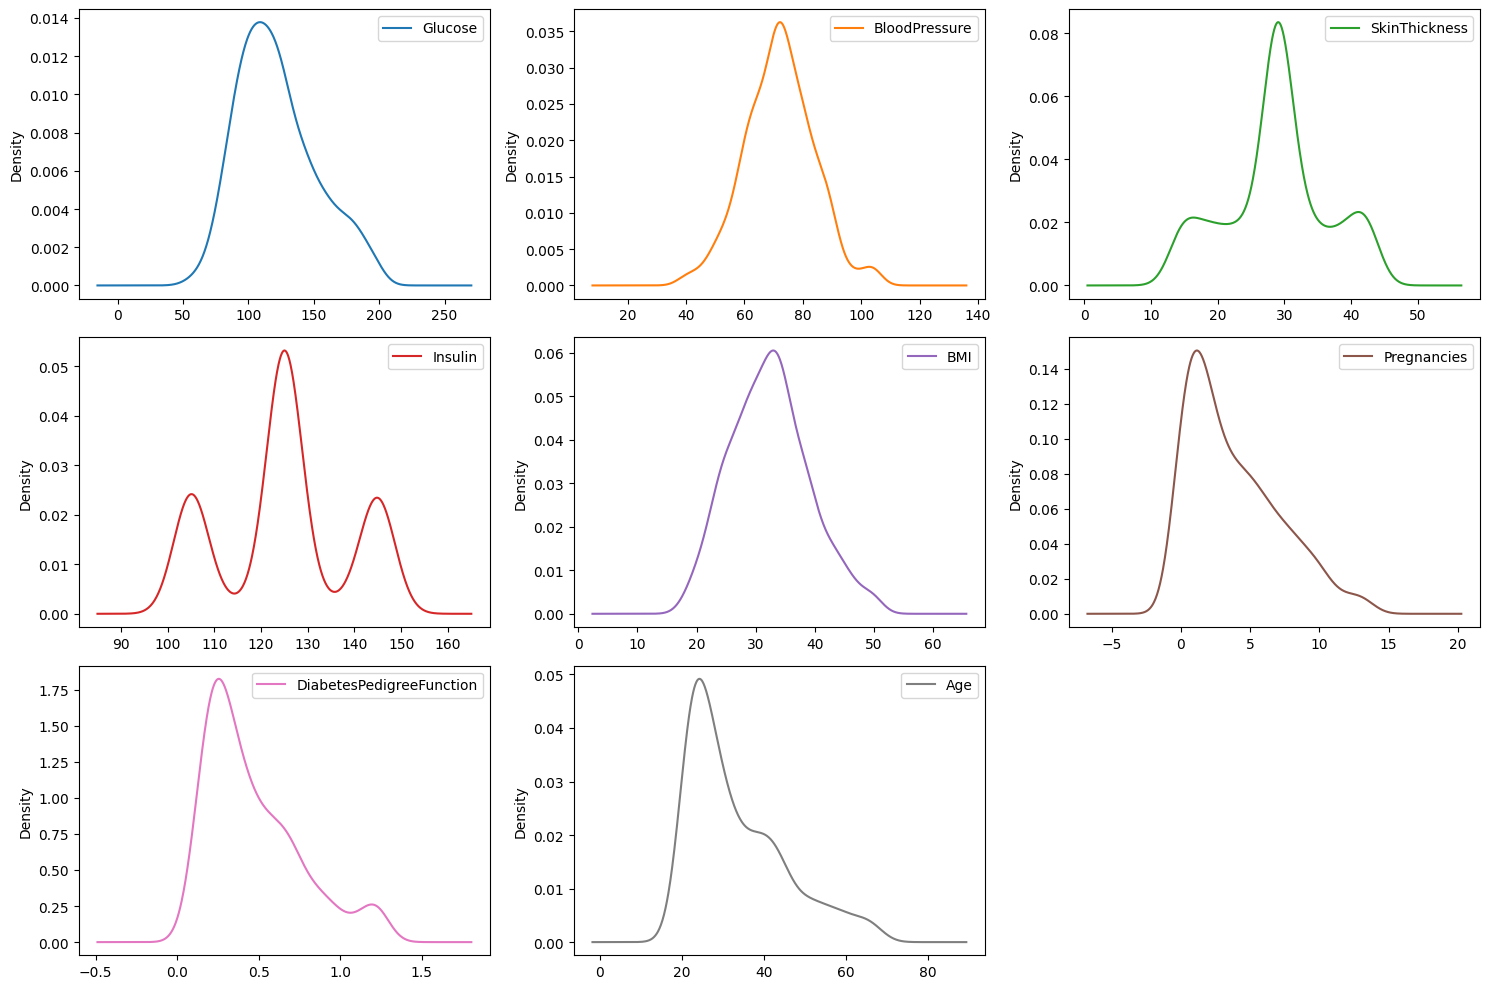

In [16]:
X_train.select_dtypes(include=['number']).plot(
    kind='kde',
    subplots=True,
    layout=(-1, 3),  # Automatically determines rows, locks columns to 3
    figsize=(15, 10),
    sharex=False     # Allows individual columns to use their own x-axis scale
)

plt.tight_layout()

In [17]:
# encoder_scaler = ColumnTransformer(
#     transformers=[
#         ('age_scaler',StandardScaler(),['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'])
#     ],
#     remainder='passthrough',
#     verbose_feature_names_out = False
# )
# encoder_scaler.set_output(transform='pandas')

# encoder_scaler.fit(X_train)

# X_train = encoder_scaler.transform(X_train)
# X_test = encoder_scaler.transform(X_test)


In [18]:
standard_scaler = Pipeline(
    steps=[
        ('scaler',StandardScaler())
    ]
)

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ('standard_scaler',standard_scaler,['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']),
    ],
    remainder='drop'
)
preprocessor

ColumnTransformer(transformers=[('standard_scaler',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Pregnancies', 'Glucose', 'BloodPressure',
                                  'SkinThickness', 'Insulin', 'BMI',
                                  'DiabetesPedigreeFunction', 'Age'])])

In [20]:
depths = range(1, 21)
train_accuracy = []
test_accuracy = []

In [21]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
from sklearn.metrics import accuracy_score,precision_score,recall_score

In [23]:
for dep in depths:
  model_1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=dep, random_state = 42))])

  model_1.fit(X_train, y_train)
  train_accuracy.append(accuracy_score(y_train, model_1.predict(X_train)))
  test_accuracy.append(accuracy_score(y_test, model_1.predict(X_test)))

In [24]:
print(train_accuracy)
print(test_accuracy)

[0.760586319218241, 0.7638436482084691, 0.7654723127035831, 0.7899022801302932, 0.8143322475570033, 0.8534201954397395, 0.8827361563517915, 0.9201954397394136, 0.9446254071661238, 0.9641693811074918, 0.9804560260586319, 0.990228013029316, 0.998371335504886, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.6948051948051948, 0.6948051948051948, 0.6948051948051948, 0.7922077922077922, 0.7662337662337663, 0.7402597402597403, 0.7467532467532467, 0.7207792207792207, 0.7012987012987013, 0.6818181818181818, 0.7142857142857143, 0.6883116883116883, 0.6753246753246753, 0.6753246753246753, 0.6753246753246753, 0.6753246753246753, 0.6753246753246753, 0.6753246753246753, 0.6753246753246753, 0.6753246753246753]


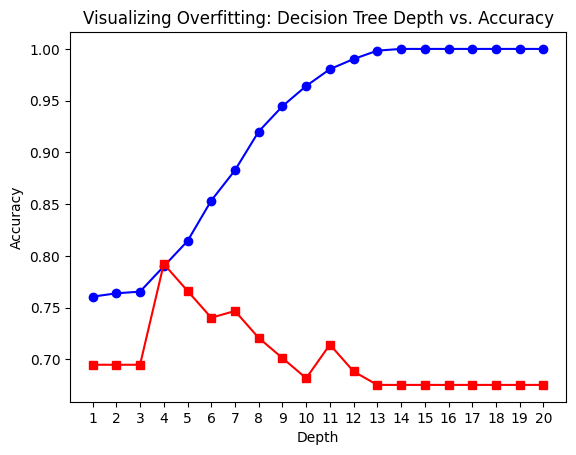

In [25]:
plt.plot(depths, train_accuracy, label = 'Train accuracy', marker = 'o', color = 'blue')

plt.plot(depths, test_accuracy, label = 'Test accuracy', marker = 's', color = 'red')

plt.xlabel('Depth')
plt.ylabel('Accuracy')
plt.title("Visualizing Overfitting: Decision Tree Depth vs. Accuracy")
plt.xticks(depths)
plt.show()

Overfitting start at depth 5

In [26]:
df = pd.read_csv('/content/adult.csv')
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [27]:
import numpy as np

In [28]:
df = df.replace(r"^\s*\?\s*$", np.nan, regex=True)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [30]:
X = df.drop('income', axis=1)
y = df['income']

In [31]:
y = y.str.contains('>').astype(int)

In [32]:
y

,income
0,0
1,0
2,0
3,0
4,0
...,...
32556,0
32557,0
32558,1
32559,0


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [34]:
X_train.drop(columns=['education', 'fnlwgt'], axis = 1, inplace = True)
X_test.drop(columns=['education', 'fnlwgt'], axis = 1, inplace = True)

In [35]:
missing_values_one_hot_encoder = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
    ]
)

In [36]:
one_hot_encoder = Pipeline(
    steps=[
        ('encoder',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
    ]
)

In [37]:
# imputer_transformer  = ColumnTransformer(
#     transformers=[
#         ('missing_values_one_hot_encoder', missing_values_one_hot_encoder, ['workclass', 'occupation', 'native.country']),
#         ('one_hot_encoder',one_hot_encoder,['marital.status', 'relationship', 'race', 'sex'])
#     ],
#     remainder='passthrough',
#     verbose_feature_names_out = False
# )

# imputer_transformer.set_output(transform='pandas')

# imputer_transformer.fit(X_train)

# X_train = imputer_transformer.transform(X_train)
# X_test = imputer_transformer.transform(X_test)

# imputer_transformer

In [38]:
imputer_transformer  = ColumnTransformer(
    transformers=[
        ('missing_values_one_hot_encoder', missing_values_one_hot_encoder, ['workclass', 'occupation', 'native.country']),
        ('one_hot_encoder',one_hot_encoder,['marital.status', 'relationship', 'race', 'sex'])
    ],
    remainder='passthrough',
    verbose_feature_names_out = False
)

# imputer_transformer.set_output(transform='pandas')

# imputer_transformer.fit(X_train)

# X_train = imputer_transformer.transform(X_train)
# X_test = imputer_transformer.transform(X_test)

# imputer_transformer

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [40]:
from sklearn.pipeline import Pipeline

grid_param={
    "classifier__n_estimators" : [50, 100, 200],
    "classifier__max_features" : ['sqrt','log2'],
    "classifier__max_depth" : [5, 10, 20, None]
}

pipeline_rf = Pipeline(steps=[
    ('preprocessor', imputer_transformer), # Use the existing imputer_transformer
    ('classifier', RandomForestClassifier(random_state=42)) # RandomForest needs a random_state for reproducibility
])

grid_search_RF = GridSearchCV(
    estimator = pipeline_rf, # Use the pipeline as the estimator
    param_grid = grid_param,
    cv = 5,
    error_score='raise' # Added for better debugging
)

grid_search_RF.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('missing_values_one_hot_encoder',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['workclass',
                                                                          'occupation',...
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['marital.status',
                                                                          'relationship',
                                                                          'race',
                                                                          'sex'])],
                                                          verbose_feature_names_out=False)),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [5, 10, 20, None],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__n_estimators': [50, 100, 200]})

In [41]:
X_train

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
11219,34,Private,13,Divorced,Prof-specialty,Unmarried,White,Female,0,0,40,United-States
28304,24,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,60,United-States
30810,39,Private,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States
10958,28,Private,10,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,United-States
26814,56,Private,4,Never-married,Adm-clerical,Not-in-family,White,Male,0,0,40,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...
9561,64,State-gov,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States
21312,36,Private,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,NaN
24250,25,Private,13,Separated,Exec-managerial,Not-in-family,White,Male,0,0,40,United-States
25812,18,Self-emp-not-inc,7,Never-married,Sales,Own-child,White,Female,0,0,40,United-States


In [42]:
X_test

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
10489,28,Self-emp-not-inc,13,Never-married,Tech-support,Not-in-family,White,Male,0,0,45,United-States
25652,19,Private,9,Never-married,Handlers-cleaners,Own-child,White,Male,0,0,16,United-States
12243,47,Private,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States
25487,54,State-gov,16,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,40,United-States
5091,47,Private,9,Divorced,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...
6092,33,Self-emp-inc,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States
28260,58,Private,9,Widowed,Sales,Not-in-family,White,Male,0,0,38,United-States
2419,38,Self-emp-not-inc,10,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,7688,0,40,United-States
32531,31,Private,9,Married-civ-spouse,Machine-op-inspct,Wife,White,Female,0,0,40,United-States


In [43]:
grid_search_RF.best_params_

{'classifier__max_depth': 20,
 'classifier__max_features': 'sqrt',
 'classifier__n_estimators': 200}

In [44]:
grid_search_RF.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('missing_values_one_hot_encoder',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['workclass', 'occupation',
                                                   'native.country']),
                                                 ('one_hot_encoder',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['marital.status',
                                                   'relationship', 'race',
                                                   'sex'])],
                                   verbose_feature_names_out=False)),
                ('classifier',
                 RandomForestClassifier(max_depth=20, n_estimators=200,
                                        random_state=42))])

In [45]:
model = grid_search_RF.best_estimator_

y_pred= model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [46]:
acc_rf = accuracy_score(y_test, y_pred)

In [47]:
print(f'Best parameters: {grid_search_RF.best_params_}')
print(f'Best Cross Validation Score: {grid_search_RF.best_score_}')
print(f'Accracy score : {acc_rf}')

Best parameters: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}
Best Cross Validation Score: 0.8600275619231296
Accracy score : 0.8578228159066482
